In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
warnings.filterwarnings("ignore")

In [3]:
data_traffic = pd.read_csv(r'G:\My Drive\Data Science\smartcity\data\traffic\mumbai_traffic.csv')
data_traffic


,datetime,road_name,latitude,longitude,area,day_of_week,hour,weather,event,avg_speed,vehicle_count,congestion_level,travel_time_index
0,2025-02-05 20:00:00,Marine Drive,18.9430,72.8235,South Mumbai,Wednesday,20,Clear,NaN,40.9,2530,55.4,2.11
1,2025-12-13 18:00:00,Pedder Road,18.9680,72.8050,Malabar Hill,Saturday,18,Clear,Accident,23.6,3420,78.2,2.56
2,2025-02-19 08:00:00,S V Road,19.1550,72.8400,Bandra,Wednesday,8,Clear,NaN,40.7,1806,41.2,1.82
3,2025-03-27 07:00:00,Ghodbunder Road,19.2800,72.9600,Thane,Thursday,7,Clear,NaN,46.9,1419,31.7,1.63
4,2025-02-22 19:00:00,Marine Drive,18.9430,72.8235,South Mumbai,Saturday,19,Cloudy,NaN,39.8,2177,47.8,1.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2025-09-07 18:00:00,S V Road,19.1550,72.8400,Bandra,Sunday,18,Clear,NaN,27.1,2799,66.0,2.32
19996,2025-06-24 04:00:00,Marine Drive,18.9430,72.8235,South Mumbai,Tuesday,4,Clear,NaN,61.0,834,10.9,1.22
19997,2025-03-20 01:00:00,Western Express Highway,19.1197,72.8468,Andheri,Thursday,1,Rain,NaN,44.7,1651,35.0,1.70
19998,2025-01-28 03:00:00,Ghodbunder Road,19.2800,72.9600,Thane,Tuesday,3,Rain,NaN,49.9,1351,27.4,1.55


In [4]:
data_traffic.describe(include="all")

,datetime,road_name,latitude,longitude,area,day_of_week,hour,weather,event,avg_speed,vehicle_count,congestion_level,travel_time_index
count,20000,20000,20000.000000,20000.000000,20000,20000,20000.000000,20000,1961,20000.000000,20000.000000,20000.000000,20000.000000
unique,7869,10,NaN,NaN,10,7,NaN,3,3,NaN,NaN,NaN,NaN
top,2025-11-07 00:00:00,S V Road,NaN,NaN,Bandra,Sunday,NaN,Clear,Construction,NaN,NaN,NaN,NaN
freq,10,2080,NaN,NaN,2080,2963,NaN,11072,986,NaN,NaN,NaN,NaN
mean,NaN,NaN,19.101485,72.870507,NaN,NaN,11.498750,NaN,NaN,44.198180,1808.349650,37.756670,1.755132
std,NaN,NaN,0.092848,0.046996,NaN,NaN,6.908544,NaN,NaN,13.754151,982.734804,24.367465,0.487349
min,NaN,NaN,18.943000,72.805000,NaN,NaN,0.000000,NaN,NaN,5.000000,101.000000,0.000000,1.000000
25%,NaN,NaN,19.067000,72.835000,NaN,NaN,6.000000,NaN,NaN,33.400000,981.000000,17.300000,1.350000
50%,NaN,NaN,19.119700,72.846800,NaN,NaN,12.000000,NaN,NaN,45.100000,1729.000000,35.700000,1.710000
75%,NaN,NaN,19.155000,72.905000,NaN,NaN,17.000000,NaN,NaN,55.500000,2595.000000,57.300000,2.150000


In [5]:
data_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           20000 non-null  object 
 1   road_name          20000 non-null  object 
 2   latitude           20000 non-null  float64
 3   longitude          20000 non-null  float64
 4   area               20000 non-null  object 
 5   day_of_week        20000 non-null  object 
 6   hour               20000 non-null  int64  
 7   weather            20000 non-null  object 
 8   event              1961 non-null   object 
 9   avg_speed          20000 non-null  float64
 10  vehicle_count      20000 non-null  int64  
 11  congestion_level   20000 non-null  float64
 12  travel_time_index  20000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 2.0+ MB


In [6]:
data_traffic.isnull().sum()

datetime                 0
road_name                0
latitude                 0
longitude                0
area                     0
day_of_week              0
hour                     0
weather                  0
event                18039
avg_speed                0
vehicle_count            0
congestion_level         0
travel_time_index        0
dtype: int64

In [7]:
data_traffic.duplicated().sum()

np.int64(0)

In [8]:
# 1. Clean up column names to remove any hidden spaces
data_traffic.columns = data_traffic.columns.str.strip()

# 2. Convert the 'datetime' column to a standard pandas datetime object
data_traffic['datetime'] = pd.to_datetime(data_traffic['datetime'])
data_traffic['hour'] = pd.to_datetime(data_traffic['hour'])

# 3. Extract the date and time into separate columns
data_traffic['date'] = data_traffic['datetime'].dt.date
data_traffic['time'] = data_traffic['datetime'].dt.time

# Check the result
print(data_traffic[['datetime', 'date', 'time']].head())


             datetime        date      time
0 2025-02-05 20:00:00  2025-02-05  20:00:00
1 2025-12-13 18:00:00  2025-12-13  18:00:00
2 2025-02-19 08:00:00  2025-02-19  08:00:00
3 2025-03-27 07:00:00  2025-03-27  07:00:00
4 2025-02-22 19:00:00  2025-02-22  19:00:00


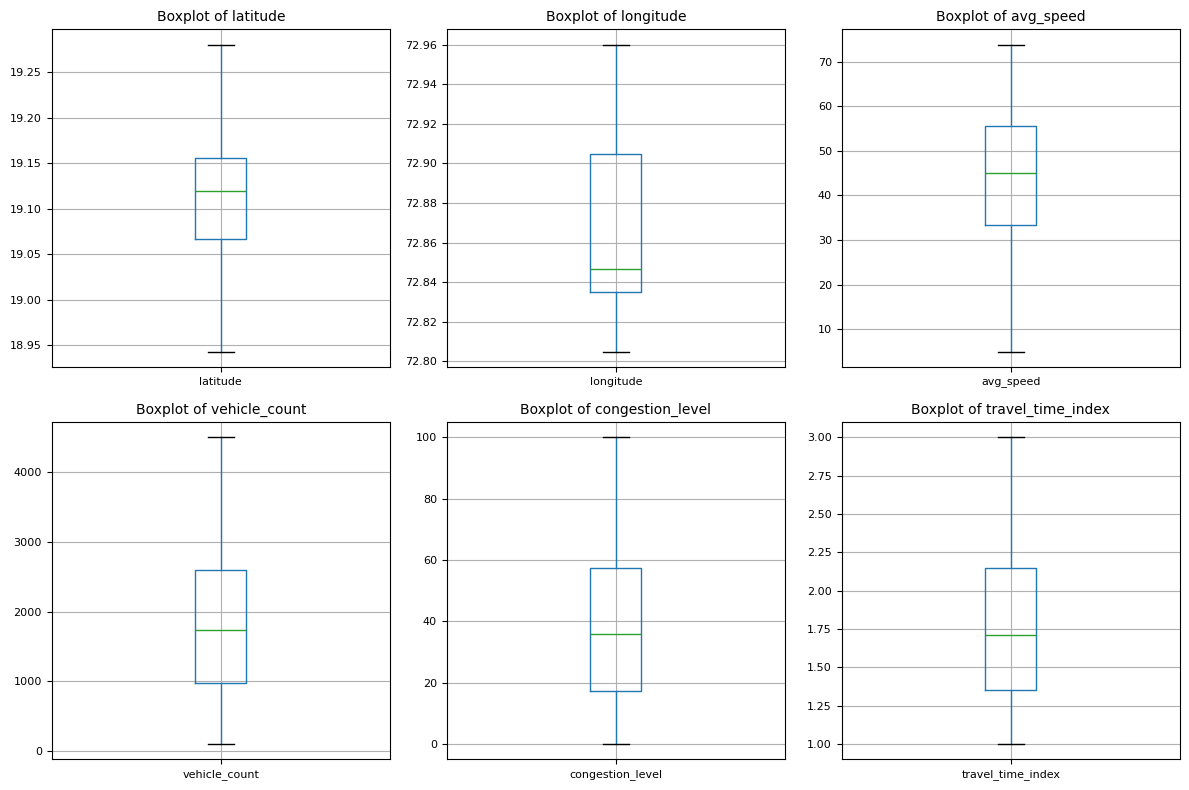

In [9]:
import math
import matplotlib.pyplot as plt

# 1. Get only the numeric columns
numeric_cols = data_traffic.select_dtypes(include="number").columns
num_plots = len(numeric_cols)

# 2. Define your grid layout structure
cols_per_row = 3  # Change this to 4 or 5 if you want more on one line
num_rows = math.ceil(num_plots / cols_per_row)

# 3. Create the master figure layout (adjust figsize to change individual box sizes)
fig, axes = plt.subplots(
    num_rows, cols_per_row, figsize=(cols_per_row * 4, num_rows * 4)
)

# 4. Flatten the axes array to make looping through a grid simple
axes = axes.flatten()

# 5. Populate each subplot slot with a small boxplot
for idx, col in enumerate(numeric_cols):
    data_traffic.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f"Boxplot of {col}", fontsize=10)
    axes[idx].tick_params(axis="both", labelsize=8)  # Makes axis text smaller

# 6. Hide empty subplot grids if your column count doesn't fill the last row perfectly
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# 7. Prevent titles and labels from overlapping
plt.tight_layout()
plt.show()


In [10]:
data_traffic.to_csv(r'G:\My Drive\Data Science\smartcity\data\traffic\mumbai_traffic_cleaned.csv', index=False)

## EDA

### Peak Traffic Hours

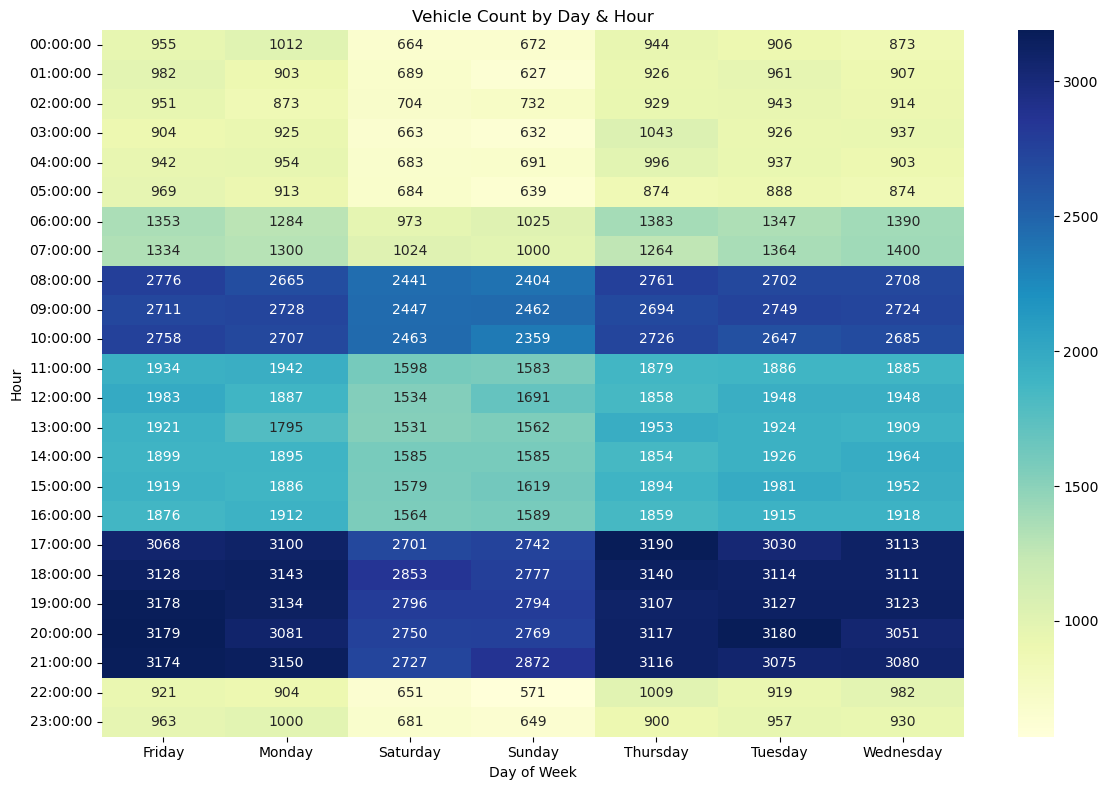

In [11]:

# 1. Make sure vehicle_count is numeric
data_traffic['vehicle_count'] = pd.to_numeric(data_traffic['vehicle_count'], errors='coerce')

# 2. Pivot: rows = hour, columns = day_of_week, values = mean vehicle_count
pivot = data_traffic.pivot_table(
    index='time',
    columns='day_of_week',
    values='vehicle_count',
    aggfunc='mean'
)

# 3. Now plot the matrix
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Vehicle Count by Day & Hour')
plt.xlabel('Day of Week')
plt.ylabel('Hour')
plt.tight_layout()
plt.show()

### Day-wise Congestion Level

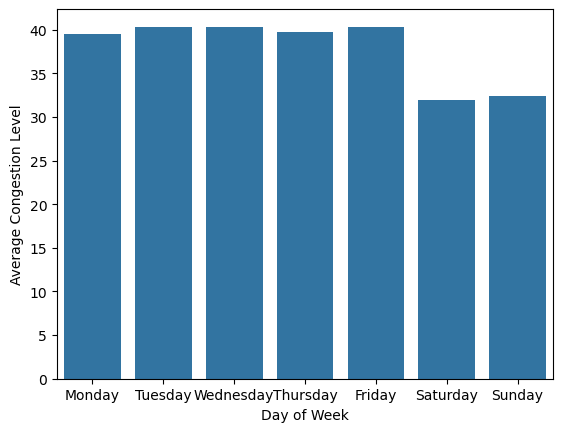

In [12]:
sns.barplot(x='day_of_week', y='congestion_level', data=data_traffic, ci=None,order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.ylabel('Average Congestion Level')          
plt.xlabel('Day of Week')          
plt.show()

### Average speed

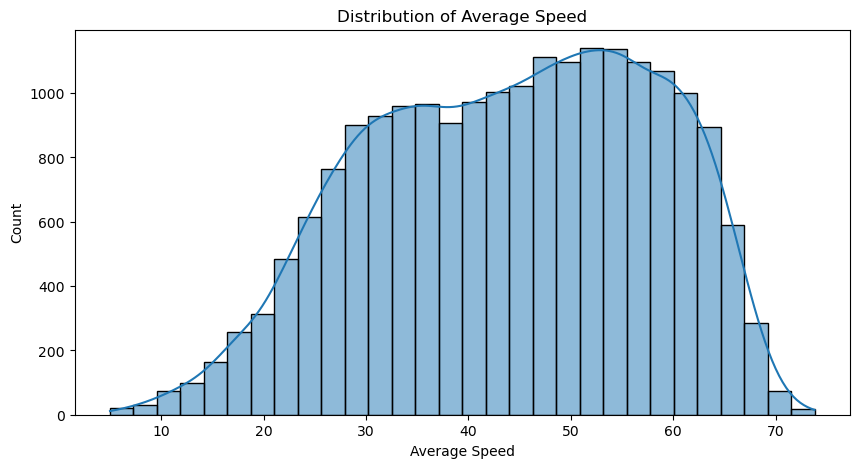

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(data_traffic["avg_speed"], bins=30, kde=True)

plt.title("Distribution of Average Speed")
plt.xlabel("Average Speed")
plt.show()

### Road-wise Analysis

In [17]:
road_congestion = (
    data_traffic.groupby("road_name")["congestion_level"]
    .mean()
    .sort_values(ascending=False)
)

road_congestion.head(10)

road_name
Marine Drive               38.299151
Western Express Highway    38.098663
Eastern Express Highway    38.060102
Link Road                  38.033996
JVLR                       37.904073
LBS Marg                   37.745035
Pedder Road                37.485885
S V Road                   37.474087
Ghodbunder Road            37.415492
BKC Road                   37.060051
Name: congestion_level, dtype: float64

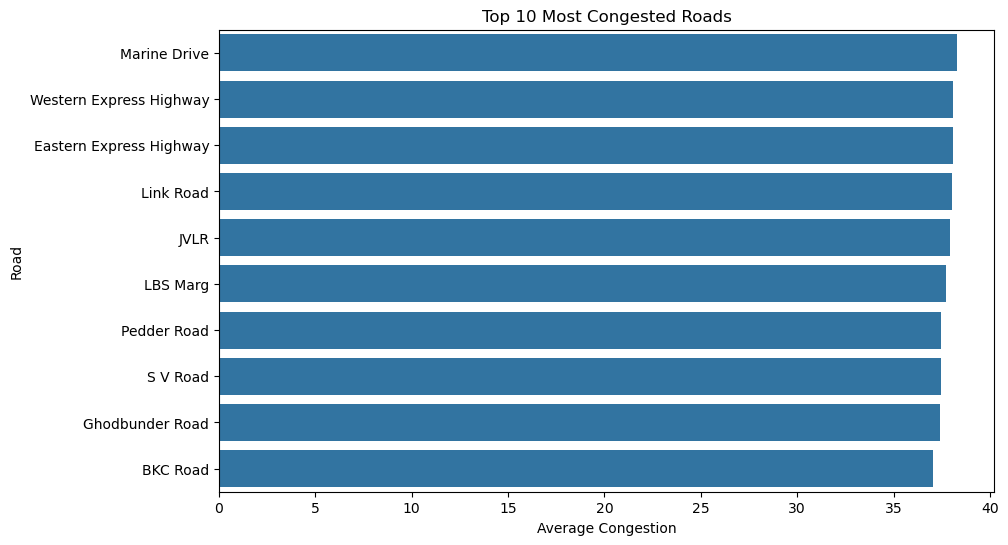

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=road_congestion.head(10).values,
    y=road_congestion.head(10).index
)

plt.title("Top 10 Most Congested Roads")
plt.xlabel("Average Congestion")
plt.ylabel("Road")
plt.show()

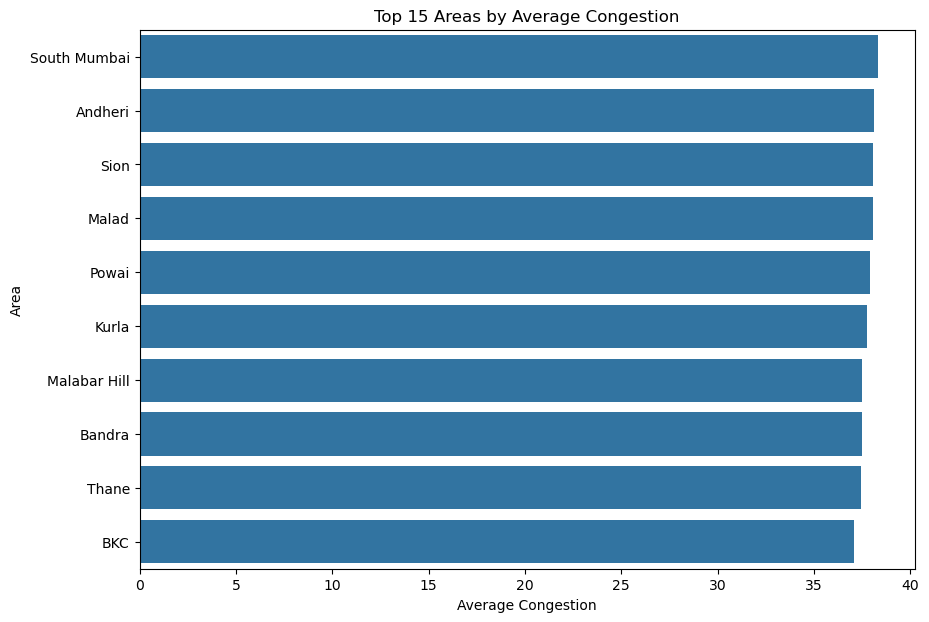

In [20]:
area_congestion = (
    data_traffic.groupby("area")["congestion_level"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=area_congestion.head(15).values,
    y=area_congestion.head(15).index
)

plt.title("Top 15 Areas by Average Congestion")
plt.xlabel("Average Congestion")
plt.ylabel("Area")
plt.show()

### Weather vs Congestion

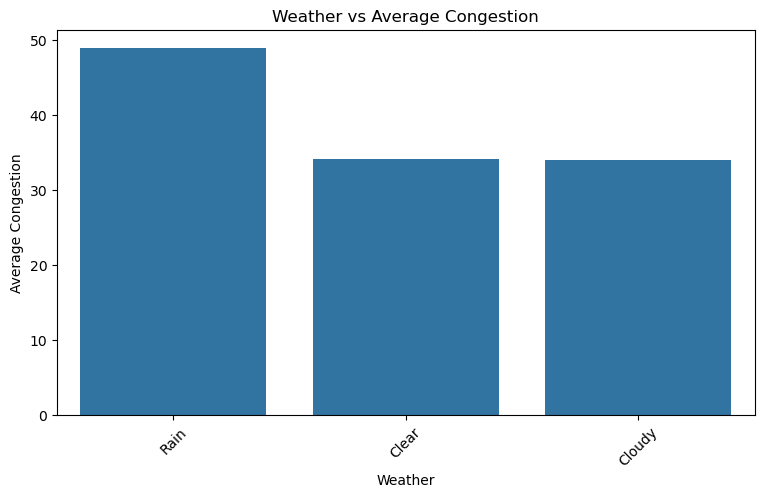

In [21]:
weather_congestion = (
    data_traffic.groupby("weather")["congestion_level"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=weather_congestion.index,
    y=weather_congestion.values
)

plt.title("Weather vs Average Congestion")
plt.xlabel("Weather")
plt.ylabel("Average Congestion")
plt.xticks(rotation=45)
plt.show()

### Event vs Congestion

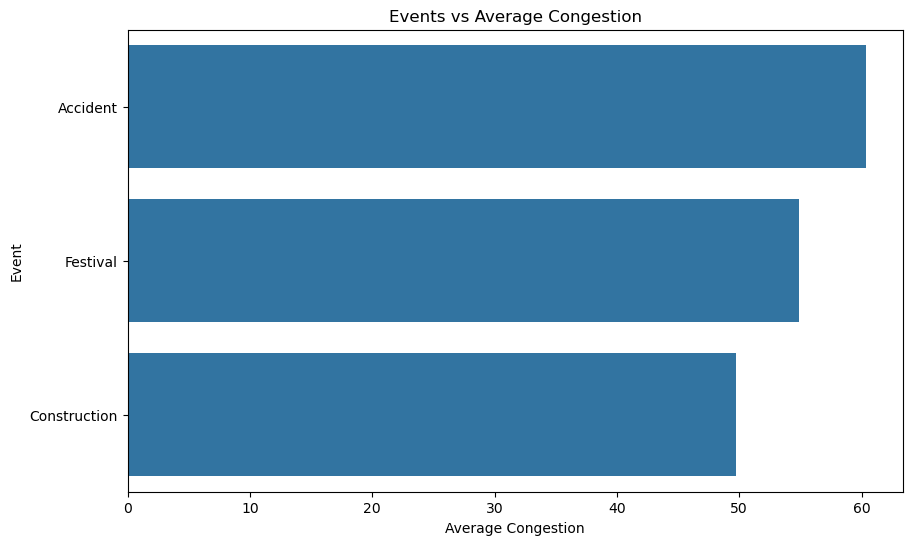

In [24]:
event_congestion = (
    data_traffic.groupby("event")["congestion_level"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=event_congestion.values,
    y=event_congestion.index
)

plt.title("Events vs Average Congestion")
plt.xlabel("Average Congestion")
plt.ylabel("Event")
plt.show()

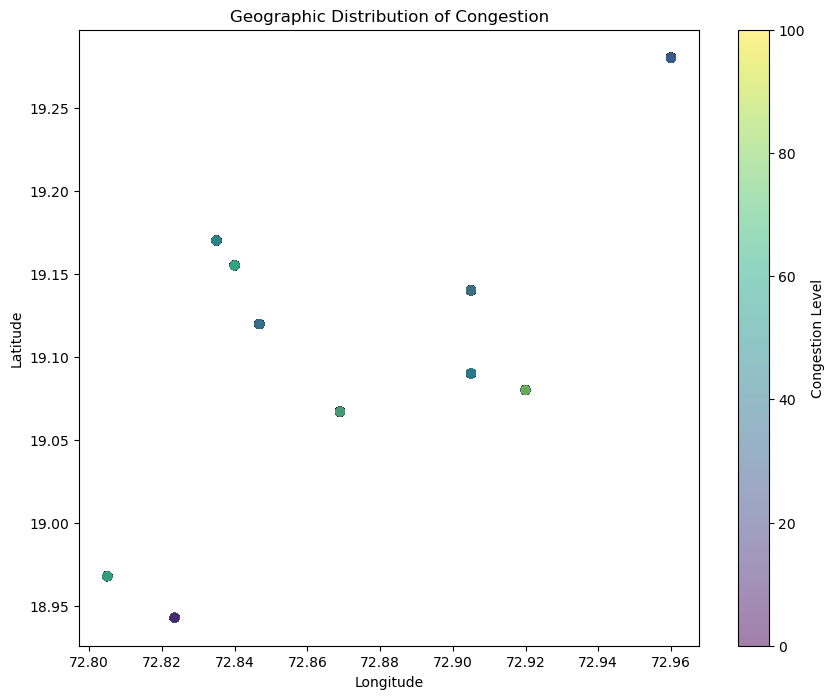

In [25]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    data_traffic["longitude"],
    data_traffic["latitude"],
    c=data_traffic["congestion_level"],
    alpha=0.5
)

plt.colorbar(scatter, label="Congestion Level")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Congestion")

plt.show()